# Bitcoin Price Forecasting using MLP and LSTM

Cryptocurrency prices are highly volatile and hard to predict — prices can 
swing sharply based on market sentiment, news, and trading activity. Despite 
this, being able to forecast even the next day's price can help traders and 
exchanges make better decisions.

In this project, we predict the next-day closing price of Bitcoin using the 
previous 30 days of price data. We build and compare two deep learning models:

1. A Multi-Layer Perceptron (MLP) — a simple feedforward neural network 
   that looks at 30 days of prices all at once, without understanding order.
2. A Long Short-Term Memory (LSTM) network — a model built specifically 
   for sequences, so it can learn patterns over time (trends, momentum).

Goal: See whether the LSTM (which understands time order) predicts better 
than the simpler MLP (which doesn't), and explain why that makes sense.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Load dataset
df = pd.read_csv("Bitcoin_Daily.csv")
df['timestamp'] = pd.to_datetime(df['timestamp'])
df.head()

,timestamp,open,high,low,close,volume
0,2019-01-01,3701.23,3810.16,3642.00,3797.14,29493.893940
1,2019-01-02,3796.45,3882.14,3750.45,3858.56,35156.463369
2,2019-01-03,3857.57,3862.74,3730.00,3766.78,29406.948359
3,2019-01-04,3767.20,3823.64,3703.57,3792.01,29519.554671
4,2019-01-05,3790.09,3840.99,3751.00,3770.96,30490.667751


# Problem definition:
We want to predict TOMORROW's Bitcoin closing price using the past 30 days
#of closing prices. This is a "time series regression" problem — the order
of the data matters. Crypto markets are known for being volatile and noisy — prices can jump or crash due to news, sentiment, or large trades, not just historical patterns. This makes forecasting genuinely hard, and we should keep that in mind when interpreting our results later.

In [3]:

print("Dataset shape:", df.shape)
print("Date range:", df['timestamp'].min(), "to", df['timestamp'].max())
df.isnull().sum()

#What this tells us: 1,674 daily records from Jan 2019 to Aug 2023, no missing values — clean data, minimal cleaning needed.

Dataset shape: (1674, 6)
Date range: 2019-01-01 00:00:00 to 2023-08-01 00:00:00


timestamp    0
open         0
high         0
low          0
close        0
volume       0
dtype: int64

# Part 2: Exploratory Data Analysis (EDA)

In [4]:
df.dtypes

timestamp    datetime64[ns]
open                float64
high                float64
low                 float64
close               float64
volume              float64
dtype: object

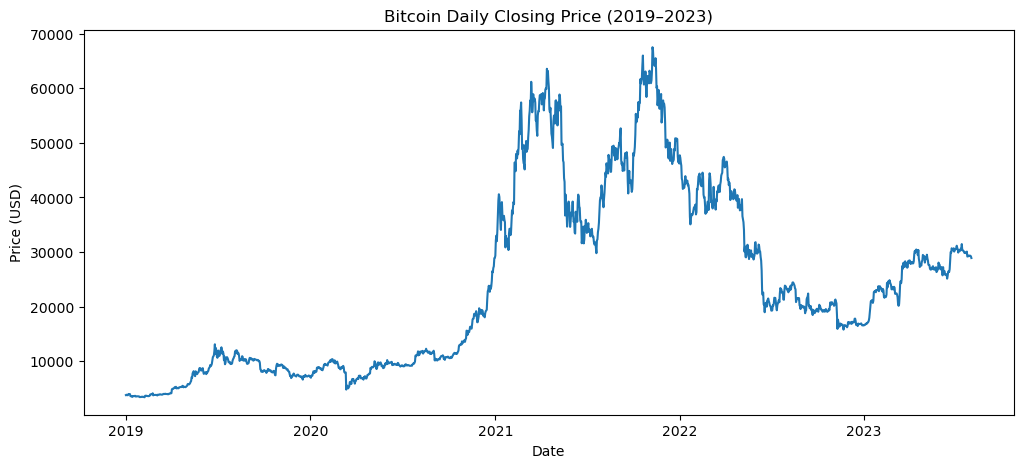

In [5]:
# Plot the daily closing price trend
plt.figure(figsize=(12,5))
plt.plot(df['timestamp'], df['close'])
plt.title("Bitcoin Daily Closing Price (2019–2023)")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.show()

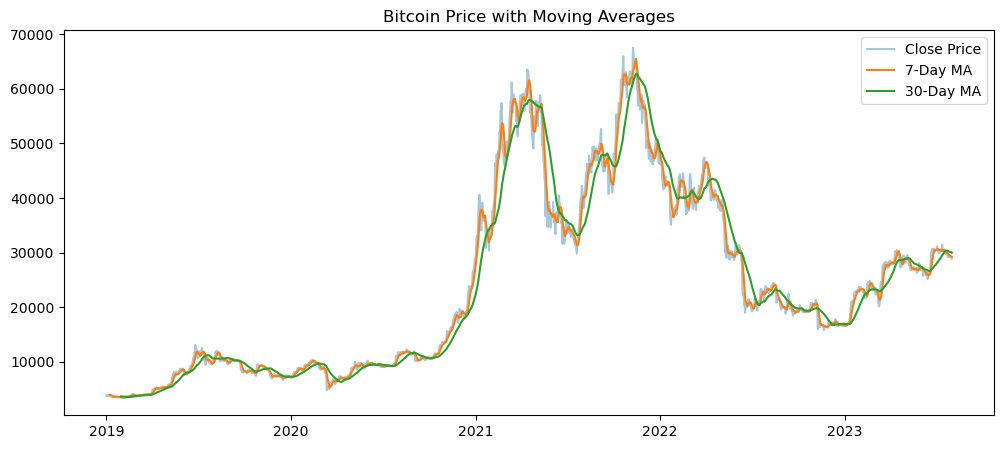

In [6]:
# Moving averages smooth out daily noise so we can see the underlying trend
df['MA7'] = df['close'].rolling(window=7).mean()
df['MA30'] = df['close'].rolling(window=30).mean()

plt.figure(figsize=(12,5))
plt.plot(df['timestamp'], df['close'], label='Close Price', alpha=0.4)
plt.plot(df['timestamp'], df['MA7'], label='7-Day MA')
plt.plot(df['timestamp'], df['MA30'], label='30-Day MA')
plt.legend()
plt.title("Bitcoin Price with Moving Averages")
plt.show()

# Interpretation:
The 7-day MA reacts quickly to price changes (short-term momentum),
while the 30-day MA is smoother and shows the longer-term trend.

When the 7-day MA crosses above the 30-day MA, it often signals upward
momentum ("bullish"); crossing below signals downward momentum ("bearish").

We can visually see large spikes (e.g. 2021 bull run) and sharp
downturns (e.g. 2022 crash), reflecting real market volatility.

# Part 3: Data Preprocessing (windowing for the model)

In [7]:
# Scale the closing price between 0 and 1
# Neural networks train much better on small, consistent number ranges
# instead of raw prices (which range from ~3,700 to ~60,000+)
scaler = MinMaxScaler()
close_scaled = scaler.fit_transform(df[['close']])

In [8]:
# Create 30-day lookback windows
# Input = past 30 days of prices, Output = the very next day's price

SEQ_LEN = 30
X, y = [], []

for i in range(SEQ_LEN, len(close_scaled)):
    X.append(close_scaled[i-SEQ_LEN:i, 0])   # past 30 days
    y.append(close_scaled[i, 0])              # next day (target)

X, y = np.array(X), np.array(y)
print("X shape:", X.shape, "y shape:", y.shape)

X shape: (1644, 30) y shape: (1644,)


In [9]:

# Split chronologically (NOT randomly!) — 80% train, 20% test
# Why chronological? Because we're predicting the future from the past.
# Shuffling would let the model "see" future prices during training,
# which is unrealistic and would cheat the evaluation (data leakage).
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

Train shape: (1315, 30) Test shape: (329, 30)


In [10]:
# Two input shapes: one for MLP, one for LSTM
# MLP just wants a flat list of 30 numbers per sample
X_train_mlp = X_train
X_test_mlp = X_test

# LSTM wants shape (samples, sequence_length, features) — it needs to know these 30 numbers are a SEQUENCE (order matters), not just 30 unrelated inputs
X_train_lstm = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test_lstm = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

print("MLP shape:", X_train_mlp.shape)
print("LSTM shape:", X_train_lstm.shape)

MLP shape: (1315, 30)
LSTM shape: (1315, 30, 1)


In [11]:
# Converting everything to PyTorch tensors
X_train_mlp_t = torch.tensor(X_train_mlp, dtype=torch.float32)
X_test_mlp_t = torch.tensor(X_test_mlp, dtype=torch.float32)

X_train_lstm_t = torch.tensor(X_train_lstm, dtype=torch.float32)
X_test_lstm_t = torch.tensor(X_test_lstm, dtype=torch.float32)

y_train_t = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
y_test_t = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

In [12]:
# Model 1: MLP (Multi-Layer Perceptron)
# This model looks at all 30 days as a flat list of numbers.
# It has NO concept of "order" — day 1 and day 30 are treated the same way,
# just as different input positions.
class MLP(nn.Module):
    def __init__(self, input_size=30):
        super(MLP, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
    def forward(self, x):
        return self.model(x)

mlp_model = MLP()

In [13]:
# Model 2: LSTM (Long Short-Term Memory)
# Unlike the MLP, the LSTM processes the 30 days ONE DAY AT A TIME, in order,
# and carries forward a "memory" of what it has seen so far. This lets it
# learn patterns like momentum and trend, not just raw values.
class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)
    def forward(self, x):
        out, (h_n, c_n) = self.lstm(x)
        # We only need the output from the LAST day (day 30) to predict day 31
        last_out = out[:, -1, :]
        return self.fc(last_out)

lstm_model = LSTMModel()

In [14]:
# Training setup — same for both models, so the comparison is fair
criterion = nn.MSELoss()
epochs = 10
lr = 0.001

def train_model(model, X_train_t, y_train_t):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    losses = []
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        output = model(X_train_t)
        loss = criterion(output, y_train_t)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
        print(f"Epoch {epoch+1}/{epochs} - Loss: {loss.item():.6f}")
    return losses

In [15]:
print("Training MLP...")
mlp_losses = train_model(mlp_model, X_train_mlp_t, y_train_t)

Training MLP...


Epoch 1/10 - Loss: 0.384208
Epoch 2/10 - Loss: 0.347404
Epoch 3/10 - Loss: 0.313978
Epoch 4/10 - Loss: 0.284674
Epoch 5/10 - Loss: 0.260544
Epoch 6/10 - Loss: 0.239960
Epoch 7/10 - Loss: 0.221581
Epoch 8/10 - Loss: 0.204698
Epoch 9/10 - Loss: 0.188281
Epoch 10/10 - Loss: 0.172319


In [16]:
print("Training LSTM...")
lstm_losses = train_model(lstm_model, X_train_lstm_t, y_train_t)

Training LSTM...


Epoch 1/10 - Loss: 0.201863
Epoch 2/10 - Loss: 0.191776
Epoch 3/10 - Loss: 0.181884
Epoch 4/10 - Loss: 0.172158
Epoch 5/10 - Loss: 0.162552
Epoch 6/10 - Loss: 0.153016
Epoch 7/10 - Loss: 0.143509
Epoch 8/10 - Loss: 0.133998
Epoch 9/10 - Loss: 0.124462
Epoch 10/10 - Loss: 0.114889


# Interpretation: watch the loss decrease across epochs.
A steadily falling loss means the model is learning. If loss stays flat or jumps around, that could mean the learning rate is off or more epochs are needed. 10 epochs is a small number, kept short here for this project — enough to see learning happen, not full convergence.

# Part 5: Model Evaluation

In [17]:
# Get predictions (turn off gradient tracking for evaluation — no training happening)
mlp_model.eval()
lstm_model.eval()

with torch.no_grad():
    mlp_preds_scaled = mlp_model(X_test_mlp_t).numpy()
    lstm_preds_scaled = lstm_model(X_test_lstm_t).numpy()

# Convert predictions and actual values back to real dollar prices
# (we scaled them to 0-1 earlier — now we reverse that)
mlp_preds = scaler.inverse_transform(mlp_preds_scaled)
lstm_preds = scaler.inverse_transform(lstm_preds_scaled)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

In [18]:
def evaluate(name, actual, predicted):
    mse = mean_squared_error(actual, predicted)
    mae = mean_absolute_error(actual, predicted)
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    print(f"{name} -> MSE: {mse:.2f} | MAE: {mae:.2f} | MAPE: {mape:.2f}%")
    return mse, mae, mape

mlp_metrics = evaluate("MLP", y_test_actual, mlp_preds)
lstm_metrics = evaluate("LSTM", y_test_actual, lstm_preds)

MLP -> MSE: 453710662.48 | MAE: 21019.15 | MAPE: 90.58%
LSTM -> MSE: 151892116.24 | MAE: 11503.85 | MAPE: 47.19%


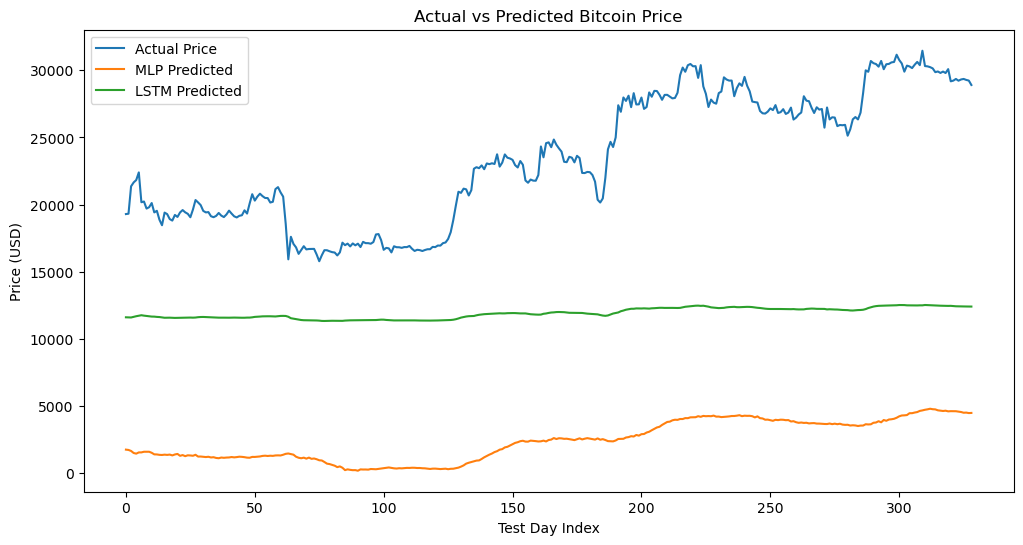

In [19]:
# Plot Actual vs Predicted for both models
plt.figure(figsize=(12,6))
plt.plot(y_test_actual, label="Actual Price")
plt.plot(mlp_preds, label="MLP Predicted")
plt.plot(lstm_preds, label="LSTM Predicted")
plt.legend()
plt.title("Actual vs Predicted Bitcoin Price")
plt.xlabel("Test Day Index")
plt.ylabel("Price (USD)")
plt.show()

# Interpretation:
Compare the two lines against the actual price. The model that tracks
sharp ups/downs (trend reversals) more closely is doing a better job
of capturing time-based patterns. Typically LSTM tracks trend direction
more smoothly since it's designed to learn sequence patterns, while MLP
tends to lag or produce noisier predictions since it treats the 30 days
as unordered inputs.

Whichever model has the LOWER MSE/MAE/MAPE numerically performed better
in this test set 

# Why is prediction hard?
Bitcoin prices are driven heavily by external factors our model never sees:
news events, regulatory announcements, social media sentiment, whale
trades, and overall market panic/euphoria. Our model only looks at past
PRICE patterns, not the news or emotions driving those prices — so it
will always miss sudden shocks.

# How can better models help traders/exchanges?
- Portfolio risk reduction: more accurate forecasts help traders size
positions and set stop-losses more confidently.
- Better entry/exit timing: predicting short-term direction can help
decide when to buy or sell.
- Early detection of trend reversals: catching a shift from uptrend to
downtrend early can prevent large losses.

# Limitations:
#- Model simplicity: only 10 training epochs and basic architectures —
a real trading system would need much more tuning and data.
- Data noise: crypto prices are naturally noisy and can behave randomly
in the short term.
- Unmodeled events: things like regulatory crackdowns or exchange
collapses (e.g. FTX) cannot be predicted from price history alone.